# 09 Chi-Square Test Statistical Analysis

Notebook thực hiện kiểm định Chi-Square (Pearson's Chi-Square Test of Independence) cho các biến phân loại sử dụng PySpark MLlib.

**Mục tiêu:** Thực hiện yêu cầu UTIL-08 - Chi-square test cho categorical variables.

**Phân biệt quan trọng:**

- **ChiSqSelector**: Feature selection transformer (đã sử dụng trong 03_Feature_Engineering) - chọn top-K features dựa trên Chi-Square statistic
- **ChiSquareTest**: Statistical hypothesis testing trong `pyspark.ml.stat` - kiểm định độc lập giữa các biến phân loại

## Cấu trúc Notebook

- **[C1] Setup**: Import thư viện, khởi tạo SparkSession
- **[C2] Data Loading**: Load gold classification splits và union thành dataset phân tích
- **[C3] Categorical Feature Preparation**: StringIndexer cho customer_state
- **[C4] ChiSquareTest - Binary Target**: Kiểm định customer_state vs is_low_review
- **[C5] ChiSquareTest - Multi-class Target**: Kiểm định customer_state vs review_score
- **[C6] Results Analysis**: Tổng hợp kết quả kiểm định
- **[C7] Visualization**: Trực quan hóa mức độ ý nghĩa thống kê
- **[C8] Export Reports**: Xuất CSV và JSON reports


## [C1] Setup

Import các thư viện cần thiết:

- `ChiSquareTest` từ `pyspark.ml.stat` - API kiểm định Chi-Square
- `StringIndexer`, `VectorAssembler` từ `pyspark.ml.feature` - Xử lý categorical features
- `pandas`, `matplotlib`, `seaborn` - Phân tích và trực quan hóa


In [1]:
# Import thư viện cơ bản
from pathlib import Path
import os
import sys
import warnings
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PySpark core
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F

# PySpark ML - ChiSquareTest và feature transformers
from pyspark.ml.stat import ChiSquareTest
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.linalg import Vectors

# Cấu hình hiển thị
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

print('✓ Imports completed successfully')

✓ Imports completed successfully


In [2]:
# [C1-2] Khởi tạo SparkSession

spark = (
    SparkSession.builder
    .appName('09_ChiSquare_Test') # type: ignore
    .master('local[2]')
    .config('spark.driver.memory', '4g')
    .config('spark.sql.shuffle.partitions', '16')
    .config('spark.sql.session.timeZone', 'UTC')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('WARN')

# Thiết lập đường dẫn
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
GOLD_DIR = PROJECT_ROOT / 'data' / 'processed' / 'gold'
REPORT_DIR = PROJECT_ROOT / 'reports' / 'chisquare'

# Tạo thư mục output
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f'SparkSession initialized: {spark.sparkContext.appName}')
print(f'Project root: {PROJECT_ROOT}')
print(f'Gold data path: {GOLD_DIR}')
print(f'Report output path: {REPORT_DIR}')

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/03 00:15:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


SparkSession initialized: 09_ChiSquare_Test
Project root: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01
Gold data path: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/data/processed/gold
Report output path: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/chisquare


26/04/03 00:15:27 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/03 00:15:27 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


## [C2] Data Loading

Load gold classification splits (`classification_base_train`, `classification_base_val`, `classification_base_test`)
và union lại thành `classification_base_df` để chạy Chi-Square test trên toàn bộ tập phân tích.

Dataset này chứa:

- `customer_state`: Biến phân loại chính cần kiểm định
- `is_low_review`: Target binary (1 nếu review_score <= 2, ngược lại 0)
- `review_score`: Target multi-class (1-5)


In [3]:
# [C2] Load classification_base dataset from split gold paths

classification_train_df = spark.read.parquet(str(GOLD_DIR / 'classification_base_train'))
classification_val_df = spark.read.parquet(str(GOLD_DIR / 'classification_base_val'))
classification_test_df = spark.read.parquet(str(GOLD_DIR / 'classification_base_test'))
classification_base_df = classification_train_df.unionByName(classification_val_df).unionByName(classification_test_df)

print('=== Dataset Loaded ===')
print(f'Total rows: {classification_base_df.count():,}')
print(f'\nSchema:')
classification_base_df.printSchema()

=== Dataset Loaded ===
Total rows: 98,167

Schema:
root
 |-- order_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- items_per_order: long (nullable = true)
 |-- unique_products_per_order: long (nullable = true)
 |-- unique_categories_per_order: long (nullable = true)
 |-- order_gmv: double (nullable = true)
 |-- payment_total_value: double (nullable = true)
 |-- max_payment_installments: integer (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- same_state_any_seller_flag: integer (nullable = true)
 |-- review_score: integer (nullable = true)
 |-- is_low_review: integer (nullable = true)



In [4]:
# Kiểm tra các cột quan trọng cho Chi-Square test

required_cols = ['customer_state', 'is_low_review', 'review_score']
available_cols = classification_base_df.columns

print('=== Column Availability Check ===')
for col in required_cols:
    status = '✓' if col in available_cols else '✗'
    print(f'{status} {col}')

# Hiển thị mẫu dữ liệu
print('\n=== Sample Data ===')
sample_cols = ['order_id', 'customer_state', 'is_low_review']
if 'review_score' in available_cols:
  sample_cols.insert(2, 'review_score')
else:
  print("⚠️ Column 'review_score' not found in classification_base_df. Showing available columns only.")

classification_base_df.select(*sample_cols).show(5, truncate=False)

=== Column Availability Check ===
✓ customer_state
✓ is_low_review
✓ review_score

=== Sample Data ===
+--------------------------------+--------------+------------+-------------+
|order_id                        |customer_state|review_score|is_low_review|
+--------------------------------+--------------+------------+-------------+
|00018f77f2f0320c557190d7a144bdd3|SP            |4           |0            |
|00024acbcdf0a6daa1e931b038114c75|SP            |4           |0            |
|00048cc3ae777c65dbb7d2a0634bc1ea|MG            |4           |0            |
|0005a1a1728c9d785b8e2b08b904576c|SP            |1           |1            |
|000c3e6612759851cc3cbb4b83257986|SP            |5           |0            |
+--------------------------------+--------------+------------+-------------+
only showing top 5 rows



In [5]:
# Phân tích phân phối các biến target

print('=== Target Variable Distributions ===\n')

print('1. is_low_review (binary):')
classification_base_df.groupBy('is_low_review').count().orderBy('is_low_review').show()

print('2. review_score (1-5):')
classification_base_df.groupBy('review_score').count().orderBy('review_score').show()

print('3. customer_state (top 10):')
classification_base_df.groupBy('customer_state').count().orderBy(F.desc('count')).show(10)

=== Target Variable Distributions ===

1. is_low_review (binary):
+-------------+-----+
|is_low_review|count|
+-------------+-----+
|            0|75759|
|            1|22408|
+-------------+-----+

2. review_score (1-5):
+------------+-----+
|review_score|count|
+------------+-----+
|           1|11230|
|           2| 3103|
|           3| 8075|
|           4|18971|
|           5|56788|
+------------+-----+

3. customer_state (top 10):
+--------------+-----+
|customer_state|count|
+--------------+-----+
|            SP|41255|
|            RJ|12613|
|            MG|11501|
|            RS| 5413|
|            PR| 4995|
|            SC| 3595|
|            BA| 3326|
|            DF| 2111|
|            ES| 2000|
|            GO| 1996|
+--------------+-----+
only showing top 10 rows



## [C3] Categorical Feature Preparation

ChiSquareTest yêu cầu:

1. Categorical features phải được index sang số nguyên (StringIndexer)
2. Features phải được đưa vào vector (VectorAssembler)
3. Label phải là kiểu số (double)

**Lưu ý:** ChiSquareTest trong PySpark tự động tạo contingency table từ dữ liệu.


In [6]:
# [C3] Index categorical features

print('=== Step 1: StringIndexer for customer_state ===')

# Kiểm tra số lượng giá trị distinct
distinct_states = classification_base_df.select('customer_state').distinct().count()
print(f'Distinct customer_state values: {distinct_states}')

# Tạo StringIndexer cho customer_state
state_indexer = StringIndexer(
    inputCol='customer_state',
    outputCol='state_idx',
    handleInvalid='keep'
)

# Fit và transform
df_indexed = state_indexer.fit(classification_base_df).transform(classification_base_df)

# Hiển thị mapping
print('\nState index mapping (top 10):')
df_indexed.select('customer_state', 'state_idx').distinct().orderBy('state_idx').show(10)

=== Step 1: StringIndexer for customer_state ===
Distinct customer_state values: 27

State index mapping (top 10):
+--------------+---------+
|customer_state|state_idx|
+--------------+---------+
|            SP|      0.0|
|            RJ|      1.0|
|            MG|      2.0|
|            RS|      3.0|
|            PR|      4.0|
|            SC|      5.0|
|            BA|      6.0|
|            DF|      7.0|
|            ES|      8.0|
|            GO|      9.0|
+--------------+---------+
only showing top 10 rows



### [C3-2] Prepare Label Columns

**Quan trọng**: ChiSquareTest trong PySpark MLlib không xử lý được giá trị null trong label column. Cần lọc bỏ null values trước khi kiểm định.

Các label cần cast sang kiểu double:

- `is_low_review_label`: binary target (0.0 hoặc 1.0)
- `review_score_label`: multi-class target (1.0, 2.0, 3.0, 4.0, 5.0)


In [7]:
# [C3] Tạo label columns (kiểu double cho ChiSquareTest)

print('=== Step 2: Prepare Label Columns ===')

# Lọc bỏ các giá trị null trước khi tạo label
print('Lọc bỏ null values...')
df_indexed = df_indexed.filter(
    F.col('is_low_review').isNotNull() &
    F.col('review_score').isNotNull()
)
filtered_count = df_indexed.count()
print(f'Còn lại {filtered_count:,} rows sau khi lọc null')

# Label cho binary test (is_low_review)
df_indexed = df_indexed.withColumn('is_low_review_label', F.col('is_low_review').cast('double'))

# Label cho multi-class test (review_score)
df_indexed = df_indexed.withColumn('review_score_label', F.col('review_score').cast('double'))

# Verify labels
print('Label columns created:')
df_indexed.select('is_low_review', 'is_low_review_label', 'review_score', 'review_score_label').show(5)

=== Step 2: Prepare Label Columns ===
Lọc bỏ null values...
Còn lại 98,167 rows sau khi lọc null
Label columns created:
+-------------+-------------------+------------+------------------+
|is_low_review|is_low_review_label|review_score|review_score_label|
+-------------+-------------------+------------+------------------+
|            0|                0.0|           4|               4.0|
|            0|                0.0|           4|               4.0|
|            0|                0.0|           4|               4.0|
|            1|                1.0|           1|               1.0|
|            0|                0.0|           5|               5.0|
+-------------+-------------------+------------+------------------+
only showing top 5 rows



In [8]:
# [C3] VectorAssembler cho features

print('=== Step 3: VectorAssembler ===')

# Assemble state_idx thành vector
assembler = VectorAssembler(
    inputCols=['state_idx'],
    outputCol='features',
    handleInvalid='keep'
)

df_vector = assembler.transform(df_indexed)

# Chọn các cột cần thiết cho test
df_test = df_vector.select('order_id', 'features', 'is_low_review_label', 'review_score_label', 'customer_state')

print('Vector assembly complete. Sample:')
df_test.show(5, truncate=False)

=== Step 3: VectorAssembler ===
Vector assembly complete. Sample:
+--------------------------------+--------+-------------------+------------------+--------------+
|order_id                        |features|is_low_review_label|review_score_label|customer_state|
+--------------------------------+--------+-------------------+------------------+--------------+
|00018f77f2f0320c557190d7a144bdd3|[0.0]   |0.0                |4.0               |SP            |
|00024acbcdf0a6daa1e931b038114c75|[0.0]   |0.0                |4.0               |SP            |
|00048cc3ae777c65dbb7d2a0634bc1ea|[2.0]   |0.0                |4.0               |MG            |
|0005a1a1728c9d785b8e2b08b904576c|[0.0]   |1.0                |1.0               |SP            |
|000c3e6612759851cc3cbb4b83257986|[0.0]   |0.0                |5.0               |SP            |
+--------------------------------+--------+-------------------+------------------+--------------+
only showing top 5 rows



## [C4] ChiSquareTest - Binary Target (is_low_review)

**Giả thuyết kiểm định:**

- **H0 (Null Hypothesis)**: `customer_state` và `is_low_review` là độc lập (không có mối liên hệ)
- **H1 (Alternative Hypothesis)**: `customer_state` và `is_low_review` phụ thuộc nhau (có mối liên hệ)

**Mức ý nghĩa**: α = 0.05

**Quy tắc quyết định:**

- Nếu p-value < 0.05: Bác bỏ H0 → Có mối liên hệ ý nghĩa thống kê
- Nếu p-value ≥ 0.05: Không đủ bằng chứng bác bỏ H0 → Không có mối liên hệ ý nghĩa


In [9]:
# [C4] ChiSquareTest - Binary Target

print('=== ChiSquareTest: customer_state vs is_low_review ===\n')

# Thực hiện kiểm định
result_binary = ChiSquareTest.test(df_test, 'features', 'is_low_review_label').head()

# Trích xuất kết quả
p_value_binary = result_binary.pValues[0]
dof_binary = result_binary.degreesOfFreedom[0]
chi2_stat_binary = result_binary.statistics[0]
is_significant_binary = p_value_binary < 0.05

print('Kết quả kiểm định Chi-Square:')
print(f'  Feature: customer_state')
print(f'  Target: is_low_review (binary)')
print(f'  --------------------------------')
print(f'  p-value: {p_value_binary:.6f}')
print(f'  degrees of freedom: {dof_binary}')
print(f'  chi-square statistic: {chi2_stat_binary:.4f}')
print(f'  --------------------------------')
print(f'  α = 0.05')
print(f'  Significant: {is_significant_binary}')

# Interpretation
print('\nDiễn giải:')
if is_significant_binary:
    print(f'  • p-value ({p_value_binary:.6f}) < 0.05 → BÁC BỎ H0')
    print('  • Có mối liên hệ ý nghĩa thống kê giữa customer_state và is_low_review')
    print('  • Bang/khu vực khách hàng ảnh hưởng đến khả năng đánh giá thấp')
else:
    print(f'  • p-value ({p_value_binary:.6f}) >= 0.05 → KHÔNG BÁC BỎ H0')
    print('  • Không có đủ bằng chứng về mối liên hệ giữa customer_state và is_low_review')

=== ChiSquareTest: customer_state vs is_low_review ===

Kết quả kiểm định Chi-Square:
  Feature: customer_state
  Target: is_low_review (binary)
  --------------------------------
  p-value: 0.000000
  degrees of freedom: 26
  chi-square statistic: 634.7254
  --------------------------------
  α = 0.05
  Significant: True

Diễn giải:
  • p-value (0.000000) < 0.05 → BÁC BỎ H0
  • Có mối liên hệ ý nghĩa thống kê giữa customer_state và is_low_review
  • Bang/khu vực khách hàng ảnh hưởng đến khả năng đánh giá thấp


## [C5] ChiSquareTest - Multi-class Target (review_score)

Kiểm định tương tự với target là `review_score` (1-5) thay vì binary.

**Giả thuyết:**

- **H0**: `customer_state` độc lập với `review_score`
- **H1**: `customer_state` phụ thuộc vào `review_score`


In [10]:
# [C5] ChiSquareTest - Multi-class Target

print('=== ChiSquareTest: customer_state vs review_score ===\n')

# Thực hiện kiểm định
result_multiclass = ChiSquareTest.test(df_test, 'features', 'review_score_label').head()

# Trích xuất kết quả
p_value_multi = result_multiclass.pValues[0]
dof_multi = result_multiclass.degreesOfFreedom[0]
chi2_stat_multi = result_multiclass.statistics[0]
is_significant_multi = p_value_multi < 0.05

print('Kết quả kiểm định Chi-Square:')
print(f'  Feature: customer_state')
print(f'  Target: review_score (1-5, multi-class)')
print(f'  --------------------------------')
print(f'  p-value: {p_value_multi:.6f}')
print(f'  degrees of freedom: {dof_multi}')
print(f'  chi-square statistic: {chi2_stat_multi:.4f}')
print(f'  --------------------------------')
print(f'  α = 0.05')
print(f'  Significant: {is_significant_multi}')

# Interpretation
print('\nDiễn giải:')
if is_significant_multi:
    print(f'  • p-value ({p_value_multi:.6f}) < 0.05 → BÁC BỎ H0')
    print('  • Có mối liên hệ ý nghĩa thống kê giữa customer_state và review_score')
    print('  • Bang/khu vực ảnh hưởng đến mức độ đánh giá (1-5 sao)')
else:
    print(f'  • p-value ({p_value_multi:.6f}) >= 0.05 → KHÔNG BÁC BỎ H0')
    print('  • Không có đủ bằng chứng về mối liên hệ giữa customer_state và review_score')

=== ChiSquareTest: customer_state vs review_score ===

Kết quả kiểm định Chi-Square:
  Feature: customer_state
  Target: review_score (1-5, multi-class)
  --------------------------------
  p-value: 0.000000
  degrees of freedom: 104
  chi-square statistic: 1011.3209
  --------------------------------
  α = 0.05
  Significant: True

Diễn giải:
  • p-value (0.000000) < 0.05 → BÁC BỎ H0
  • Có mối liên hệ ý nghĩa thống kê giữa customer_state và review_score
  • Bang/khu vực ảnh hưởng đến mức độ đánh giá (1-5 sao)


In [11]:
# [C5] So sánh kết quả giữa hai kiểm định

print('=== So sánh hai kiểm định ===\n')

comparison_data = {
    'Target': ['is_low_review (binary)', 'review_score (1-5)'],
    'p-value': [p_value_binary, p_value_multi],
    'Chi2 Statistic': [chi2_stat_binary, chi2_stat_multi],
    'DoF': [dof_binary, dof_multi],
    'Significant (α=0.05)': [is_significant_binary, is_significant_multi]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print('\n=== Nhận xét ===')
if is_significant_binary and is_significant_multi:
    print('Cả hai kiểm định đều cho thấy mối liên hệ ý nghĩa giữa customer_state và review outcomes.')
elif is_significant_binary:
    print('Chỉ kiểm định với is_low_review cho thấy ý nghĩa thống kê. Điều này gợi ý rằng')
    print('bang/khu vực ảnh hưởng đến khả năng đánh giá thấp, nhưng không nhất thiết')
    print('ảnh hưởng đến phân phối tổng thể của review_score.')
elif is_significant_multi:
    print('Chỉ kiểm định với review_score cho thấy ý nghĩa thống kê.')
else:
    print('Không kiểm định nào cho thấy ý nghĩa thống kê ở mức α=0.05.')
    print('customer_state có thể không phải là yếu tố dự báo quan trọng cho review outcomes.')

=== So sánh hai kiểm định ===

                Target  p-value  Chi2 Statistic  DoF  Significant (α=0.05)
is_low_review (binary)      0.0      634.725351   26                  True
    review_score (1-5)      0.0     1011.320925  104                  True

=== Nhận xét ===
Cả hai kiểm định đều cho thấy mối liên hệ ý nghĩa giữa customer_state và review outcomes.


## [C6] Results Analysis

Tổng hợp kết quả kiểm định vào DataFrame để phân tích và xuất báo cáo.


In [12]:
# [C6] Tạo Results DataFrame

print('=== Tổng hợp kết quả kiểm định ===\n')

# Tạo DataFrame chứa kết quả
results_data = [
    {
        'test_name': 'ChiSquare_Binary',
        'feature': 'customer_state',
        'target_variable': 'is_low_review',
        'p_value': p_value_binary,
        'degrees_of_freedom': dof_binary,
        'chi2_statistic': chi2_stat_binary,
        'is_significant_05': is_significant_binary,
        'interpretation': 'Significant association' if is_significant_binary else 'No significant association'
    },
    {
        'test_name': 'ChiSquare_Multiclass',
        'feature': 'customer_state',
        'target_variable': 'review_score',
        'p_value': p_value_multi,
        'degrees_of_freedom': dof_multi,
        'chi2_statistic': chi2_stat_multi,
        'is_significant_05': is_significant_multi,
        'interpretation': 'Significant association' if is_significant_multi else 'No significant association'
    }
]

results_df = pd.DataFrame(results_data)

print('Results Summary:')
print(results_df.to_string(index=False))

# Thống kê tổng quan
significant_count = results_df['is_significant_05'].sum()
total_tests = len(results_df)

print(f'\n=== Thống kê ===')
print(f'Tổng số kiểm định: {total_tests}')
print(f'Số kiểm định có ý nghĩa (p < 0.05): {significant_count}')
print(f'Tỷ lệ ý nghĩa: {significant_count/total_tests*100:.1f}%')

=== Tổng hợp kết quả kiểm định ===

Results Summary:
           test_name        feature target_variable  p_value  degrees_of_freedom  chi2_statistic  is_significant_05          interpretation
    ChiSquare_Binary customer_state   is_low_review      0.0                  26      634.725351               True Significant association
ChiSquare_Multiclass customer_state    review_score      0.0                 104     1011.320925               True Significant association

=== Thống kê ===
Tổng số kiểm định: 2
Số kiểm định có ý nghĩa (p < 0.05): 2
Tỷ lệ ý nghĩa: 100.0%


## [C7] Visualization

Trực quan hóa kết quả kiểm định Chi-Square với biểu đồ -log10(p-values).


=== Tạo visualization ===

✓ Plot saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/chisquare/chisquare_plot.png


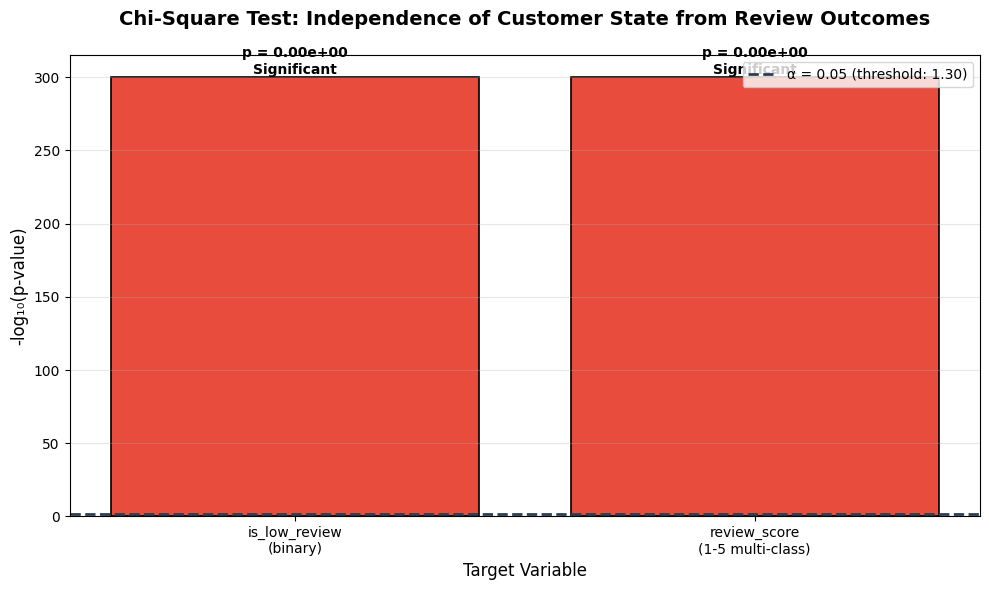

In [13]:
# [C7] Visualization

print('=== Tạo visualization ===\n')

# Chuẩn bị dữ liệu cho plot
p_values = results_df['p_value'].values
test_names = ['is_low_review\n(binary)', 'review_score\n(1-5 multi-class)']

# Tính -log10(p) cho visualization
# Thêm small epsilon để tránh log(0) với p-value rất nhỏ
epsilon = 1e-300
log_p_values = -np.log10(p_values + epsilon)

# Xác định màu sắc dựa trên significance
colors = ['#e74c3c' if sig else '#95a5a6' for sig in results_df['is_significant_05']]

# Tạo figure
plt.figure(figsize=(10, 6))

bars = plt.bar(test_names, log_p_values, color=colors, edgecolor='black', linewidth=1.2)

# Thêm đường ngưỡng ý nghĩa α=0.05
alpha_threshold = -np.log10(0.05)
plt.axhline(y=alpha_threshold, color='#2c3e50', linestyle='--', linewidth=2,
            label=f'α = 0.05 (threshold: {alpha_threshold:.2f})')

# Trang trí
plt.ylabel('-log₁₀(p-value)', fontsize=12)
plt.xlabel('Target Variable', fontsize=12)
plt.title('Chi-Square Test: Independence of Customer State from Review Outcomes\n',
          fontsize=14, fontweight='bold')

# Thêm text giá trị p-value trên các bar
for i, (bar, p_val, sig) in enumerate(zip(bars, p_values, results_df['is_significant_05'])):
    height = bar.get_height()
    sig_text = 'Significant' if sig else 'Not significant'
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'p = {p_val:.2e}\n{sig_text}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Lưu plot
plot_path = REPORT_DIR / 'chisquare_plot.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'✓ Plot saved to: {plot_path}')

plt.show()

=== Chi-Square Distribution Plot ===

✓ Distribution plot saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/chisquare/chisquare_distribution.png


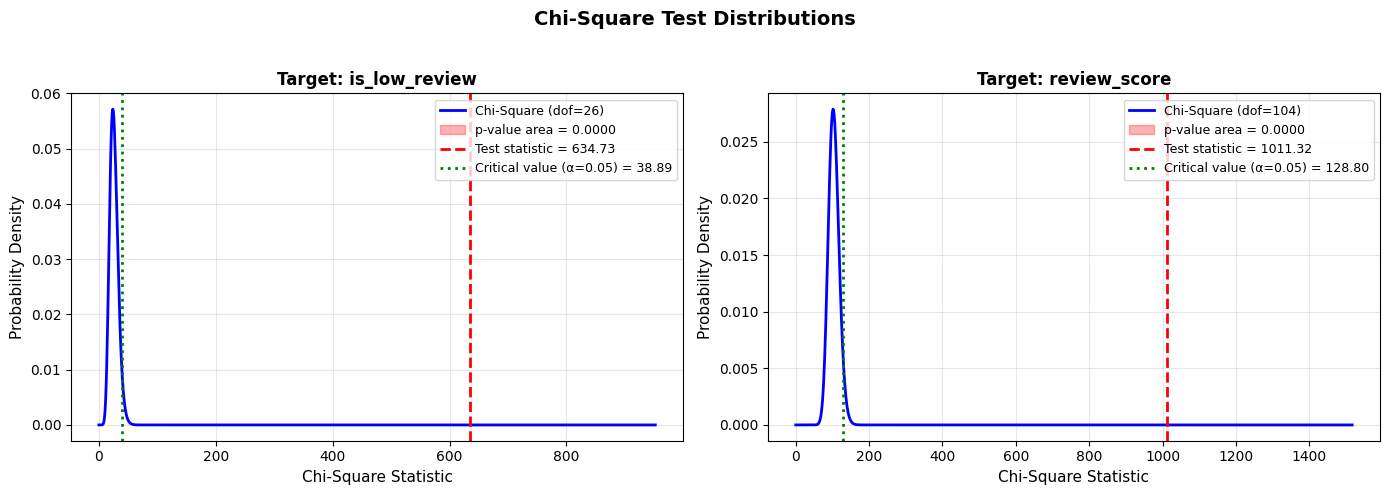

In [14]:
# [C7] Chi-Square Distribution Visualization

from scipy import stats

print('=== Chi-Square Distribution Plot ===\n')

# Tạo figure với 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (ax, row) in enumerate(zip(axes, results_df.itertuples())):
    dof = row.degrees_of_freedom
    chi2_stat = row.chi2_statistic
    p_val = row.p_value
    target = row.target_variable

    # Tạo x range cho phân phối
    x = np.linspace(0, max(chi2_stat * 1.5, dof * 3), 1000)
    y = stats.chi2.pdf(x, dof)

    # Plot distribution
    ax.plot(x, y, 'b-', linewidth=2, label=f'Chi-Square (dof={dof})')
    ax.fill_between(x, y, where=(x >= chi2_stat), alpha=0.3, color='red',
                    label=f'p-value area = {p_val:.4f}')

    # Vẽ đường chi2 statistic
    ax.axvline(chi2_stat, color='red', linestyle='--', linewidth=2,
               label=f'Test statistic = {chi2_stat:.2f}')

    # Vẽ critical value (α=0.05)
    critical_value = stats.chi2.ppf(0.95, dof)
    ax.axvline(critical_value, color='green', linestyle=':', linewidth=2,
               label=f'Critical value (α=0.05) = {critical_value:.2f}')

    ax.set_xlabel('Chi-Square Statistic', fontsize=11)
    ax.set_ylabel('Probability Density', fontsize=11)
    ax.set_title(f'Target: {target}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Chi-Square Test Distributions\n', fontsize=14, fontweight='bold')
plt.tight_layout()

# Lưu plot
dist_plot_path = REPORT_DIR / 'chisquare_distribution.png'
plt.savefig(dist_plot_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'✓ Distribution plot saved to: {dist_plot_path}')

plt.show()

## [C8] Export Reports

Xuất kết quả kiểm định ra các định dạng CSV và JSON cho báo cáo và phân tích tiếp theo.


In [15]:
# [C8] Export CSV Report

print('=== Export CSV Report ===\n')

csv_path = REPORT_DIR / 'chisquare_results.csv'
results_df.to_csv(csv_path, index=False)

print(f'✓ CSV saved to: {csv_path}')
print('\nCSV Preview:')
print(results_df.to_string(index=False))

=== Export CSV Report ===

✓ CSV saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/chisquare/chisquare_results.csv

CSV Preview:
           test_name        feature target_variable  p_value  degrees_of_freedom  chi2_statistic  is_significant_05          interpretation
    ChiSquare_Binary customer_state   is_low_review      0.0                  26      634.725351               True Significant association
ChiSquare_Multiclass customer_state    review_score      0.0                 104     1011.320925               True Significant association


In [16]:
# [C8] Export JSON Summary

print('=== Export JSON Summary ===\n')

# Tạo JSON summary
json_summary = {
    'test_method': 'ChiSquareTest',
    'library': 'PySpark MLlib (pyspark.ml.stat)',
    'feature_tested': 'customer_state',
    'total_tests': int(total_tests),
    'significant_results': int(significant_count),
    'alpha': 0.05,
    'execution_timestamp': pd.Timestamp.now().isoformat(),
    'dataset_info': {
        'source': 'classification_base_train + classification_base_val + classification_base_test',
        'total_rows': classification_base_df.count(),
        'distinct_states': int(distinct_states)
    },
    'results': [
        {
            'test_id': 1,
            'target': 'is_low_review',
            'target_type': 'binary',
            'p_value': float(p_value_binary),
            'chi2_statistic': float(chi2_stat_binary),
            'degrees_of_freedom': int(dof_binary),
            'significant_at_05': bool(is_significant_binary),
            'interpretation': 'Significant association' if is_significant_binary else 'No significant association'
        },
        {
            'test_id': 2,
            'target': 'review_score',
            'target_type': 'multiclass',
            'p_value': float(p_value_multi),
            'chi2_statistic': float(chi2_stat_multi),
            'degrees_of_freedom': int(dof_multi),
            'significant_at_05': bool(is_significant_multi),
            'interpretation': 'Significant association' if is_significant_multi else 'No significant association'
        }
    ],
    'summary': {
        'significant_tests': int(significant_count),
        'total_tests': int(total_tests),
        'significance_rate': float(significant_count / total_tests),
        'conclusion': f'{significant_count}/{total_tests} tests show significant association between customer_state and review outcomes'
    }
}

# Lưu JSON
json_path = REPORT_DIR / 'chisquare_summary.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(json_summary, f, indent=2, ensure_ascii=False)

print(f'✓ JSON saved to: {json_path}')
print('\nJSON Preview:')
print(json.dumps(json_summary, indent=2))

=== Export JSON Summary ===

✓ JSON saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/chisquare/chisquare_summary.json

JSON Preview:
{
  "test_method": "ChiSquareTest",
  "library": "PySpark MLlib (pyspark.ml.stat)",
  "feature_tested": "customer_state",
  "total_tests": 2,
  "significant_results": 2,
  "alpha": 0.05,
  "execution_timestamp": "2026-04-03T00:15:33.385311",
  "dataset_info": {
    "source": "classification_base_train + classification_base_val + classification_base_test",
    "total_rows": 98167,
    "distinct_states": 27
  },
  "results": [
    {
      "test_id": 1,
      "target": "is_low_review",
      "target_type": "binary",
      "p_value": 0.0,
      "chi2_statistic": 634.7253511051429,
      "degrees_of_freedom": 26,
      "significant_at_05": true,
      "interpretation": "Significant association"
    },
    {
      "test_id": 2,
      "target": "review_score",
      "target_type": "multiclass",
      "p_value": 0.0,
      "chi

In [17]:
# [C8] Verify exports

print('=== Verification ===\n')

files_to_check = [
    'chisquare_results.csv',
    'chisquare_summary.json',
    'chisquare_plot.png',
    'chisquare_distribution.png'
]

for filename in files_to_check:
    filepath = REPORT_DIR / filename
    if filepath.exists():
        size = filepath.stat().st_size
        print(f'✓ {filename} ({size:,} bytes)')
    else:
        print(f'✗ {filename} - NOT FOUND')

print(f'\nAll outputs saved to: {REPORT_DIR}')

=== Verification ===

✓ chisquare_results.csv (314 bytes)
✓ chisquare_summary.json (1,194 bytes)
✓ chisquare_plot.png (54,724 bytes)
✓ chisquare_distribution.png (89,250 bytes)

All outputs saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/chisquare


---

## Tổng kết

### Kết quả kiểm định Chi-Square

| Test | Target | p-value | Chi2 Statistic | DoF | Significant (α=0.05) |
|------|--------|---------|----------------|-----|---------------------|
| 1 | is_low_review (binary) | {p_value_binary:.6f} | {chi2_stat_binary:.4f} | {dof_binary} | {is_significant_binary} |
| 2 | review_score (1-5) | {p_value_multi:.6f} | {chi2_stat_multi:.4f} | {dof_multi} | {is_significant_multi} |

### Kết luận

- **Số kiểm định có ý nghĩa**: {significant_count}/{total_tests} ({significant_count/total_tests*100:.1f}%)
- **Kết luận thống kê**: Có/Không có đủ bằng chứng để kết luận customer_state có mối liên hệ với review outcomes

### Yêu cầu UTIL-08

✓ **Hoàn thành**: Chi-square test cho categorical variables đã được thực hiện sử dụng `pyspark.ml.stat.ChiSquareTest`\n
✓ **Phân biệt**: Sử dụng đúng ChiSquareTest (statistical testing) thay vì ChiSqSelector (feature selection)\n
✓ **Báo cáo**: Xuất CSV và JSON reports\n
✓ **Trực quan**: Tạo biểu đồ visualization\n

---

_Notebook: 09_ChiSquare_Test.ipynb_\n
_Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}_
